# importing libraries

In [92]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif,chi2
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import scipy.stats as stats


from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb




from sklearn.preprocessing import PowerTransformer




from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [2]:
FILE_PATH=os.path.join(os.getcwd(),"..",r"datasets","churn-data.csv")
df=pd.read_csv(FILE_PATH)

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [6]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


* `Explatory data analysis (EDA)`

In [7]:
df.Geography.unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [8]:
df.Gender.unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [9]:
df.Tenure.unique().tolist()

[2, 1, 8, 7, 4, 6, 3, 10, 5, 9, 0]

In [10]:
sorted_tenure=df.Tenure.unique().tolist()

In [11]:
sorted_tenure.sort()

In [12]:
print(sorted_tenure)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


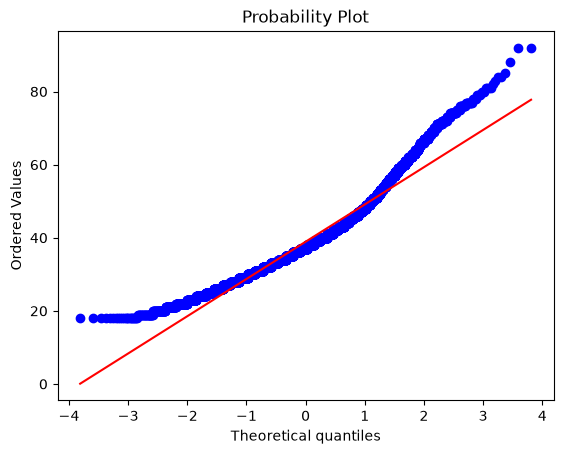

In [13]:

# Create the Q-Q plot
stats.probplot(df["Age"], dist="norm", plot=plt)

# Display the plot
plt.show()

In [14]:
# PowerTransformer(method=['yeo-johnson', 'box-cox'])
normal_transformer=PowerTransformer(method='box-cox',standardize=True)


In [15]:
new_age=normal_transformer.fit_transform(df[["Age"]])

array([[<Axes: title={'center': '0'}>]], dtype=object)

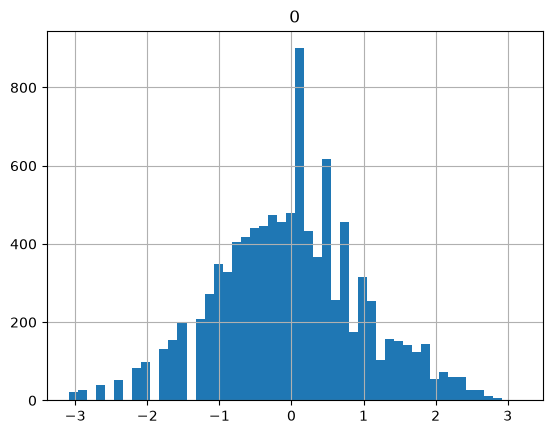

In [16]:
pd.DataFrame(new_age).hist(bins=50)

C:\Users\yossif\AppData\Local\Temp\ipykernel_16676\2107702826.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 3000x1000 with 0 Axes>

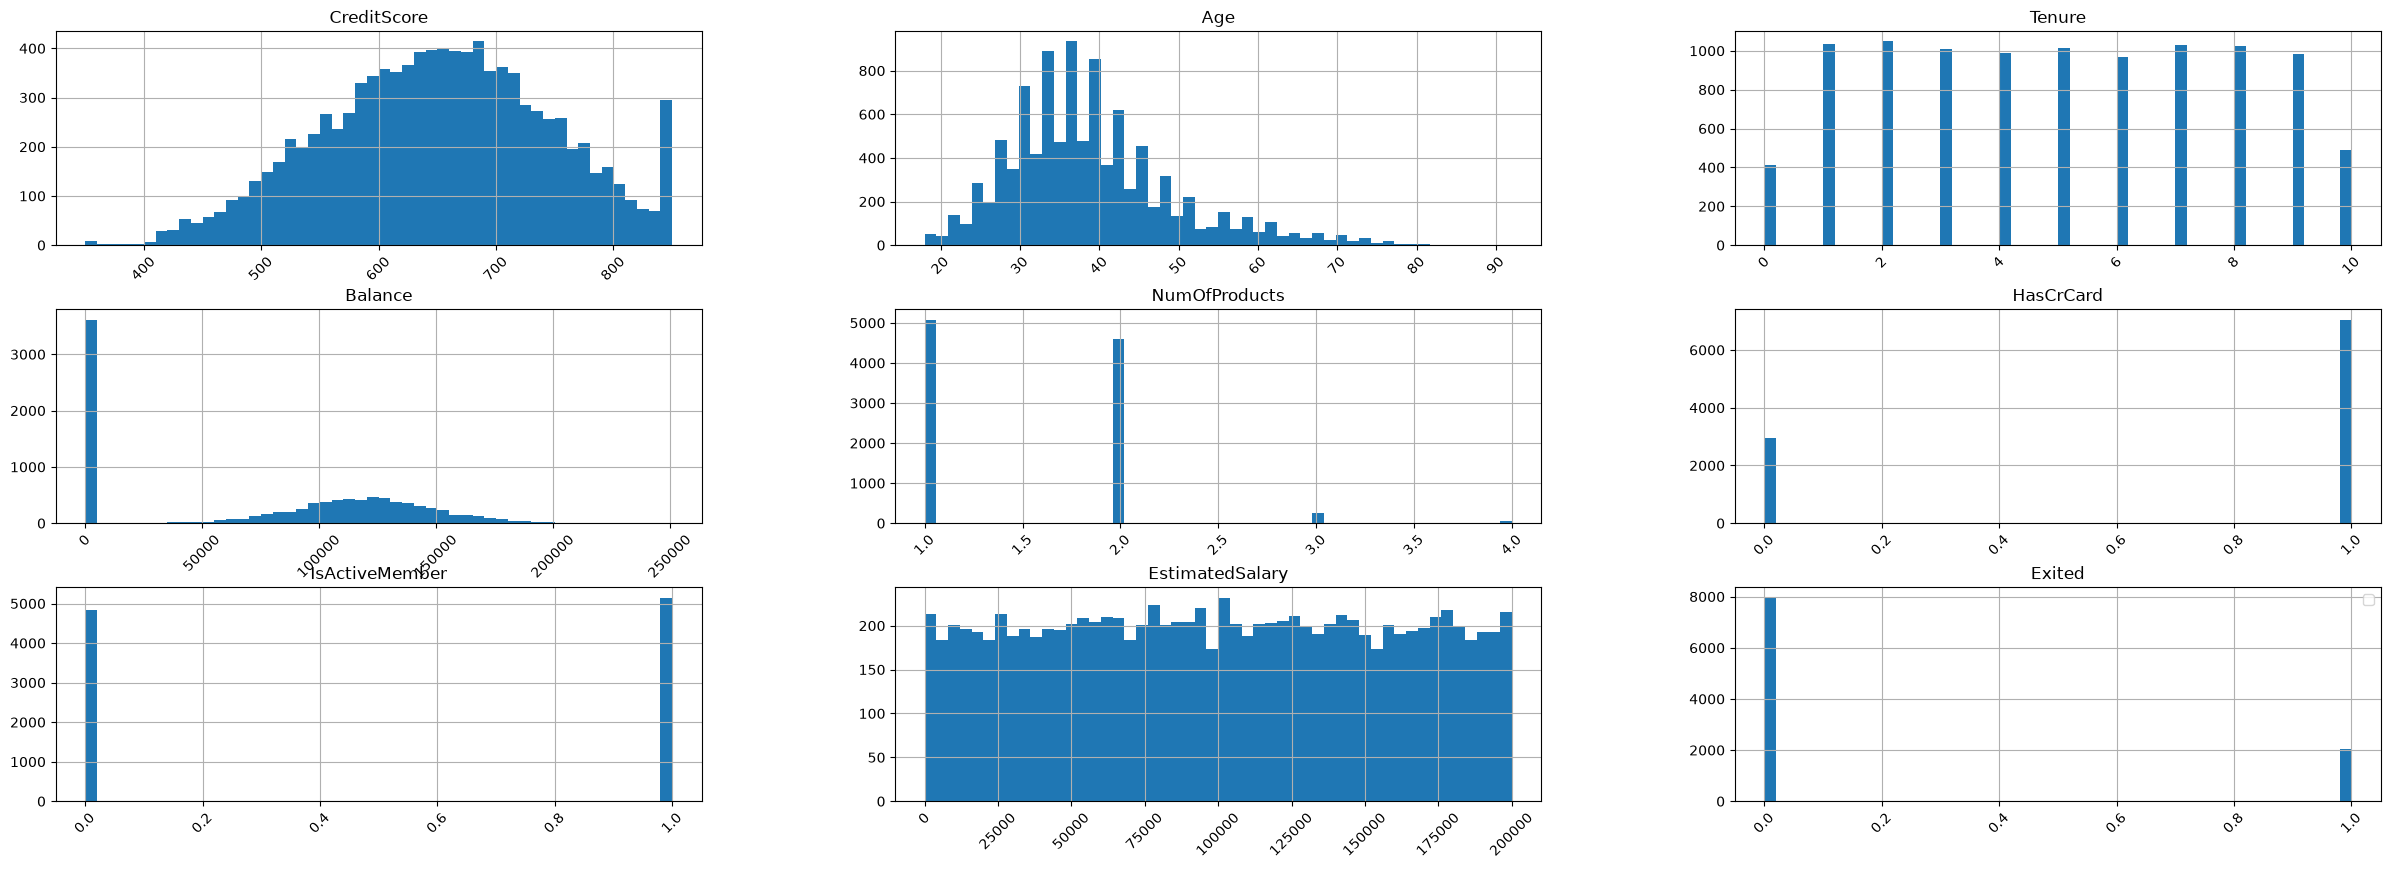

In [17]:
plt.figure(figsize=(30,10))
df.hist(bins=50,xrot=45,figsize=(30,10))
plt.xticks()
plt.legend()
plt.show()

In [18]:
indexs=df[df["Age"]>80].index.to_list()

In [19]:
df.drop(index=indexs,inplace=True)

C:\Users\yossif\AppData\Local\Temp\ipykernel_16676\2107702826.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 3000x1000 with 0 Axes>

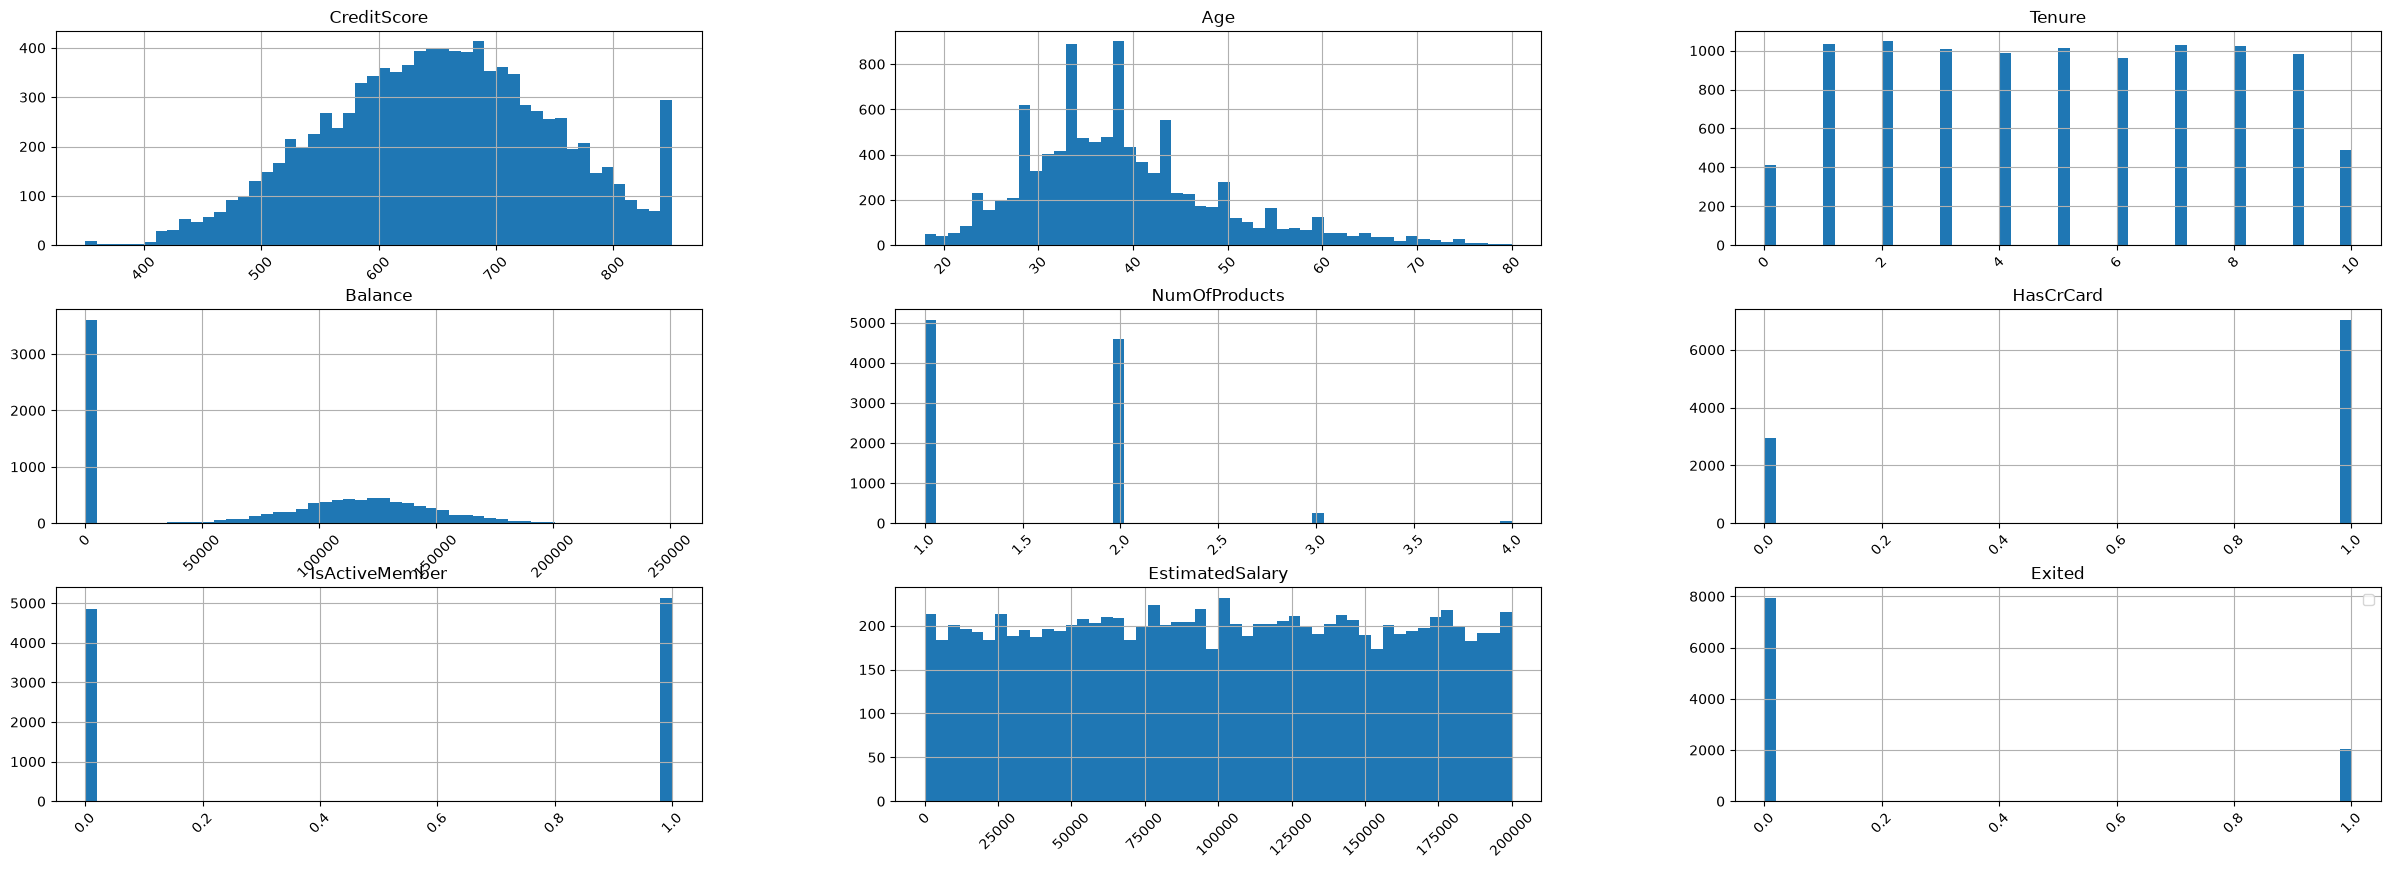

In [20]:
plt.figure(figsize=(30,10))
df.hist(bins=50,xrot=45,figsize=(30,10))
plt.xticks()
plt.legend()
plt.show()

<Axes: xlabel='Exited', ylabel='count'>

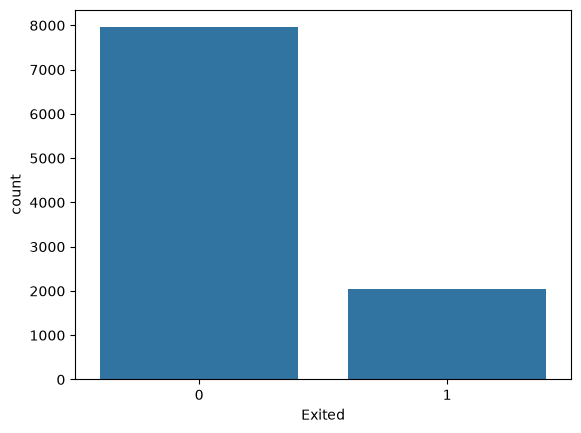

In [21]:
sns.countplot(data=df,x="Exited")

In [22]:
df.head(0)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [23]:
df.groupby("Gender")["EstimatedSalary"].agg(["mean"])

,mean
Gender,
Female,100575.998277
Male,99671.901194


<Axes: xlabel='Tenure', ylabel='Exited'>

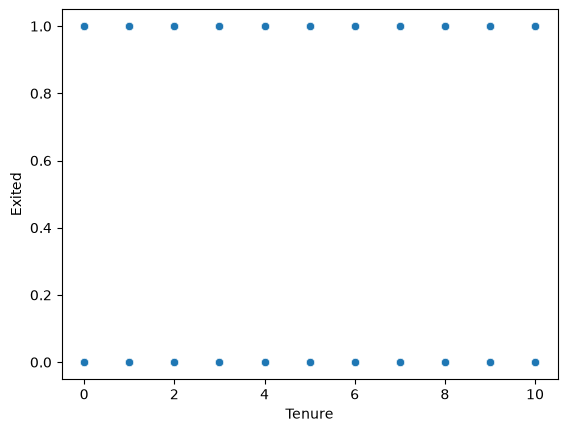

In [24]:
sns.scatterplot(data=df,x="Tenure",y="Exited")

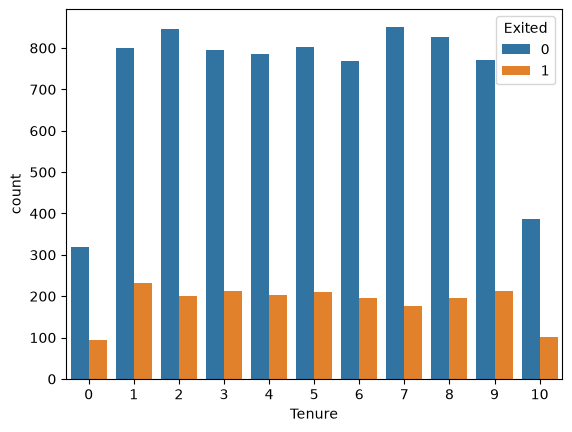

In [25]:
sns.countplot(data=df,x="Tenure",hue="Exited");

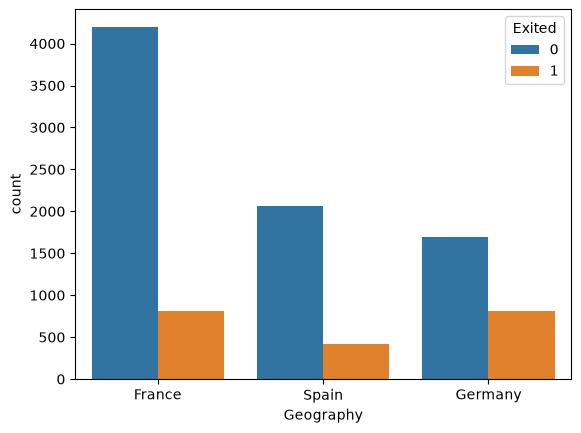

In [26]:
sns.countplot(data=df,x="Geography",hue="Exited");

* `Spliting Data`

In [27]:
df.head(0)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [28]:
X=df.drop(columns=["Exited"])
y=df["Exited"]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,shuffle=True,test_size=.2,stratify=y)

* `feature selection and preprocessing`

In [30]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
category_columns=["Geography","Gender"]
numarical_columns=["Age","Balance"]
ready_columns=["Tenure","NumOfProducts","IsActiveMember"]

In [32]:
_,pvalues=f_classif(X=X_train[numarical_columns],y=y_train)

In [33]:
pvalues

array([1.15359217e-149, 3.56368021e-025])

In [34]:
pvalues<.05

array([ True,  True])

In [35]:
X_train.drop(columns=["CreditScore","EstimatedSalary"],inplace=True)
X_test.drop(columns=["CreditScore","EstimatedSalary"],inplace=True)

In [36]:
category_columns=["Geography","Gender"]


In [37]:
oe=OrdinalEncoder()

In [38]:
encoder_categ=oe.fit_transform(X=X_train[category_columns])

In [39]:
_,pvals=chi2(X=encoder_categ,y=y_train)

In [40]:
_,pvals=chi2(X=X_train[ready_columns],y=y_train)

In [41]:
pvals

array([6.36015039e-02, 6.55133468e-02, 7.15759804e-22])

In [42]:
pvals<.05

array([False, False,  True])

In [43]:
X_train.drop(columns=["HasCrCard"],inplace=True)
X_test.drop(columns=["HasCrCard"],inplace=True)

In [44]:
X_train

,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember
2591,Germany,Male,38,2,148430.55,1,1
1980,France,Female,30,9,0.00,2,1
9866,France,Male,24,4,0.00,2,0
7871,France,Female,36,3,91711.59,1,1
5504,France,Male,32,2,120452.40,2,0
...,...,...,...,...,...,...,...
7889,Germany,Male,57,9,138456.03,2,1
7159,France,Female,59,6,55328.40,1,0
5990,France,Female,32,9,125321.84,2,1
6764,France,Male,37,6,0.00,1,1


* `Pipeline`

In [45]:
# category_columns -> impute mode || ohe encoding 
# numarical_columns -> impute mean || standard scalar
# ready_columns ->impute mode

In [46]:
category_pipeline=Pipeline([
    ("category_imputer",SimpleImputer(strategy="most_frequent")),
    ("category_encoder",OneHotEncoder(sparse_output=False,drop="first"))
])
numarical_pipeline=Pipeline([
    ("numarical_imputer",SimpleImputer(strategy="median")),
    ("numarical_scaler",StandardScaler())
])
ready_pipeline=Pipeline([
    ("ready_imputer",SimpleImputer(strategy="most_frequent"))
])

In [47]:
processor=ColumnTransformer(transformers=[
    ("category",category_pipeline,category_columns),
    ("numarical",numarical_pipeline,numarical_columns),
    ("ready",ready_pipeline,ready_columns)
])

In [48]:
X_train_final=processor.fit_transform(X_train)
X_test_final=processor.transform(X_test)

In [49]:
X_train_final

array([[1., 0., 1., ..., 2., 1., 1.],
       [0., 0., 0., ..., 9., 2., 1.],
       [0., 0., 1., ..., 4., 2., 0.],
       ...,
       [0., 0., 0., ..., 9., 2., 1.],
       [0., 0., 1., ..., 6., 1., 1.],
       [1., 0., 1., ..., 4., 1., 1.]], shape=(7990, 8))

In [50]:
X_test_final

array([[0., 0., 0., ..., 2., 2., 0.],
       [1., 0., 0., ..., 9., 1., 1.],
       [1., 0., 1., ..., 5., 2., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 1.],
       [1., 0., 1., ..., 7., 1., 0.],
       [0., 0., 1., ..., 3., 1., 1.]], shape=(1998, 8))

# Dealing with unbalanaced data
* `Method one :using class weight `
* `Method two :decreasing the bigger `
* `Method three :increasing the less `

* `Method one :using class weight `


In [51]:
weights=1-np.bincount(y_train)/len(y_train)
weights

array([0.20387985, 0.79612015])

In [52]:
weights=weights/sum(weights)
weights

array([0.20387985, 0.79612015])

In [53]:
dict_weights={}

for i in range(2):
    dict_weights[i]=weights[i]
dict_weights

{0: np.float64(0.20387984981226537), 1: np.float64(0.7961201501877346)}

In [54]:
LogisticRegression(class_weight=dict_weights)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: np.float64(0....7984981226537), 1: np.float64(0.7961201501877346)}"
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might wa

* `Method two :decreasing the bigger `


In [55]:
under_sampler=RandomUnderSampler()

* `Method three :increasing the less `

In [57]:
smote=SMOTE(k_neighbors=5,sampling_strategy=.7,random_state=42) #sampling_strategy = ratio between minority class to majority class
X_train_sampled,y_train_sampled=smote.fit_resample(X_train_final,y_train)

In [61]:
y_train_sampled.value_counts()[1]/y_train_sampled.value_counts()[0]

np.float64(0.699889954409684)

In [ ]:
MODEL_FOLDER_PATH=os.path.join(os.getcwd(),"..","Models")
os.mkdir(MODEL_FOLDER_PATH)

* `Dumping Pipeline`

In [64]:
joblib.dump(processor,os.path.join(MODEL_FOLDER_PATH,"processor.pkl"))

['l:\\courses\\AI Agoor Course\\NEW Material Udemy\\04- Machine Learning\\sec 8\\MY PROJECT\\notebooks\\..\\Models\\processor.pkl']

* `Applying Classification using Logistic Regression`

In [68]:
lr=LogisticRegression(C=1.5)
lr.fit(X_train_final,y_train)
y_train_predict=lr.predict(X_train_final)
y_test_predict=lr.predict(X_test_final)

print(f"F1 Score For train Data = {f1_score(y_train,y_train_predict)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_predict)}")

F1 Score For train Data = 0.3155979990904957
F1 Score For test Data = 0.35664335664335667


In [81]:
lr=LogisticRegression(C=1.5,class_weight=dict_weights) #-> Considering class weights
lr.fit(X_train_final,y_train)
y_train_predict=lr.predict(X_train_final)
y_test_predict=lr.predict(X_test_final)

print(f"F1 Score For train Data = {f1_score(y_train,y_train_predict)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_predict)}")


F1 Score For train Data = 0.4970465981185736
F1 Score For test Data = 0.5029635901778154


In [ ]:
lr=LogisticRegression(C=1.5) #-> Considering Oversampling Using Smote
lr.fit(X_train_sampled,y_train_sampled)
y_train_predict=lr.predict(X_train_final)
y_test_predict=lr.predict(X_test_final)

print(f"F1 Score For train Data = {f1_score(y_train,y_train_predict)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_predict)}")

F1 Score For train Data = 0.49460625674217906
F1 Score For test Data = 0.4957983193277311


<Axes: >

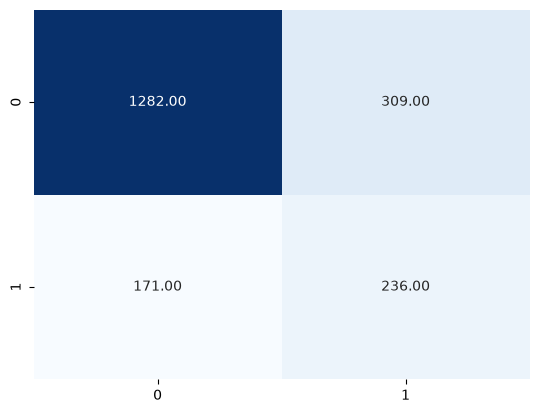

In [86]:
sns.heatmap(confusion_matrix(y_test,y_test_predict),cmap="Blues",annot=True,cbar=False,fmt=".2f")

In [87]:
print(classification_report(y_test,y_test_predict))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1591
           1       0.43      0.58      0.50       407

    accuracy                           0.76      1998
   macro avg       0.66      0.69      0.67      1998
weighted avg       0.79      0.76      0.77      1998



* `Applying Classification using Random Forest`

In [88]:
#-> Considering class weights
rf=RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42,class_weight=dict_weights)
rf.fit(X_train_final,y_train)
y_train_forest=rf.predict(X_train_final)
y_test_forest=rf.predict(X_test_final)

print(f"F1 Score For train Data = {f1_score(y_train,y_train_forest)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_forest)}")

F1 Score For train Data = 0.6007434944237918
F1 Score For test Data = 0.5784313725490197


In [91]:
#-> Considering Oversampling Using Smote
rf=RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42)
rf.fit(X_train_sampled,y_train_sampled)
y_train_forest=rf.predict(X_train_final)
y_test_forest=rf.predict(X_test_final)

print(f"F1 Score For train Data = {f1_score(y_train,y_train_forest)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_forest)}")

F1 Score For train Data = 0.623608017817372
F1 Score For test Data = 0.6075949367088608


* `Applying Tuning`

In [101]:
base_rf=RandomForestClassifier(n_estimators=150,max_depth=5,random_state=42,class_weight=dict_weights)

params_best_grid={
    "n_estimators" : np.arange(50,500,50),
    "max_depth" : np.arange(4,24,4)
}

In [102]:
grid_search=GridSearchCV(base_rf,params_best_grid,cv=5,verbose=3,n_jobs=-1,scoring="f1")

In [103]:
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 4, 8, 12, 16, 20]), 'n_estimators': array([ 50, 1...50, 400, 450])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_searc

In [104]:
grid_search.fit(X_train_final,y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 4, 8, 12, 16, 20]), 'n_estimators': array([ 50, 1...50, 400, 450])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_searc

In [107]:
best_rf_grid=grid_search.best_estimator_

In [108]:
grid_search.best_params_

{'max_depth': np.int64(8), 'n_estimators': np.int64(100)}

In [111]:
y_train_tuned_forest=best_rf_grid.predict(X_train_final)
y_test_tuned_forest=best_rf_grid.predict(X_test_final)
print(f"F1 Score For train Data = {f1_score(y_train,y_train_tuned_forest)}")
print(f"F1 Score For test Data = {f1_score(y_test,y_test_tuned_forest)}")

F1 Score For train Data = 0.6608561907203281
F1 Score For test Data = 0.6085192697768763


In [112]:
joblib.dump(best_rf_grid,os.path.join(MODEL_FOLDER_PATH,"RandomForestTuned.pkl"))

['l:\\courses\\AI Agoor Course\\NEW Material Udemy\\04- Machine Learning\\sec 8\\MY PROJECT\\notebooks\\..\\Models\\RandomForestTuned.pkl']

In [ ]:
best_rf_grid.feature_importances_

array([0.0624663 , 0.00932476, 0.0299607 , 0.40980481, 0.11943401,
       0.0415086 , 0.2538638 , 0.07363703])

In [ ]:
processor.get_feature_names_out().tolist()

array(['category__Geography_Germany', 'category__Geography_Spain',
       'category__Gender_Male', 'numarical__Age', 'numarical__Balance',
       'ready__Tenure', 'ready__NumOfProducts', 'ready__IsActiveMember'],
      dtype=object)

In [127]:
featureImportance=pd.DataFrame({
            "Feature":processor.get_feature_names_out().tolist(),

             "imp":best_rf_grid.feature_importances_}
             
             
             )

In [130]:
featureImportance.sort_values(ascending=False,by="imp")

,Feature,imp
3,numarical__Age,0.409805
6,ready__NumOfProducts,0.253864
4,numarical__Balance,0.119434
7,ready__IsActiveMember,0.073637
0,category__Geography_Germany,0.062466
5,ready__Tenure,0.041509
2,category__Gender_Male,0.029961
1,category__Geography_Spain,0.009325
